In [69]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
from sklearn import datasets
from sklearn.manifold import Isomap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

import requests

from sklearn.cluster import KMeans
from sklearn import preprocessing

In [4]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [58]:
#t90 = data[6].astype(float)
#fluence = data[9].astype(float)

t90 = np.array(data[6], dtype=float)
fluence = np.array(data[9], dtype=float)


In [139]:
fluence_clean = fluence[((fluence != -999) & (t90 != -999) & (fluence != 0))]
t90_clean = t90[((fluence != -999) & (t90 != -999) & (fluence != 0))]

In [124]:
'''
fluence_2 = fluence[fluence != -999]
t90_2 =  t90[fluence != -999]

fluence_clean = fluence_clean[fluence_2 != 0]
t90_clean = t90_clean[fluence_2 != 0]
'''

Text(0, 0.5, 'fluence')

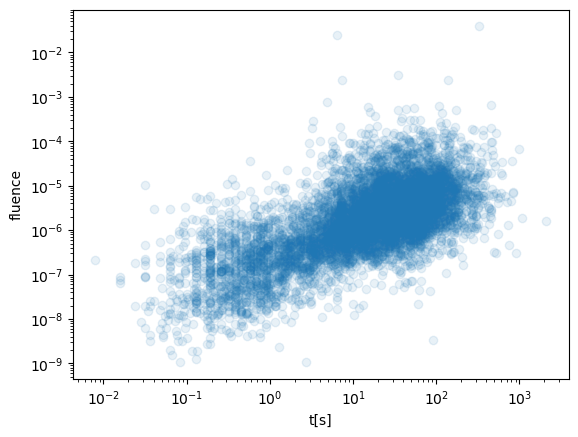

In [140]:
plt.scatter(t90_clean,fluence_clean,alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('t[s]')
plt.ylabel('fluence')

In [141]:
np.log(t90_clean)

array([2.95491028, 2.88931564, 0.29565024, ..., 1.1429481 , 5.34030348,
       1.64557696])

Text(0, 0.5, 'fluence [$erg/cm^2\t$]')

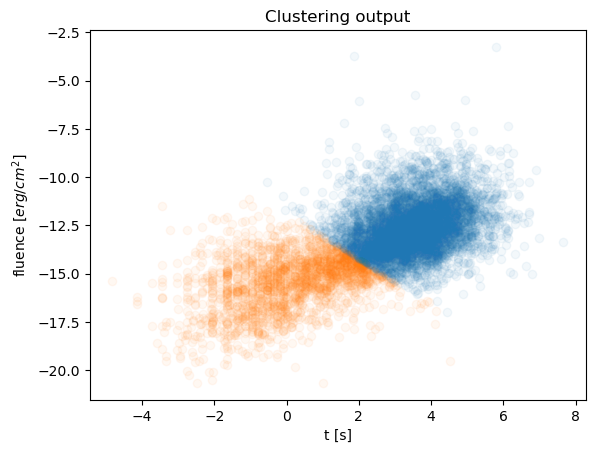

In [148]:
X = np.array([np.log(t90_clean), np.log(fluence_clean)])
X = X.T
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.05)

plt.title(r'Clustering output')

plt.xlabel('t [s]')
plt.ylabel(r'fluence [$erg/cm^2	$]')